# Explorativní analýza
Pro analýzu byla použita datová sada Stroke Prediction Dataset ze stránky Kaggle.com (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?resource=download).
## Prozkoumání atributů
Nejprve načteme data z csv souboru do pandas dataframe. 


In [34]:
import pandas as pd
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df = df.drop(columns="id")
df["hypertension"] = df["hypertension"].astype("str")
df["heart_disease"] = df["heart_disease"].astype("str")
df["stroke"] = df["stroke"].astype("str")

Provedeme analýzu dat jako celek. Vypíšeme si datové typy jednotlivých atribůtu a pár dat od každého pro základní pochopení dat. 

In [35]:
print("Informace o datech:")
print(df.info())

print("Ukázka dat:")
print(df.head())


Informace o datech:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   object 
 3   heart_disease      5110 non-null   object 
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   object 
dtypes: float64(3), object(8)
memory usage: 439.3+ KB
None
Ukázka dat:
   gender   age hypertension heart_disease ever_married      work_type  \
0    Male  67.0            0             1          Yes        Private   
1  Female  61.0            0  

Dále si zobrazíme souhrné statistiky o datech pro získání ještě lepší představi o datech.

In [36]:
print("Popisná statistika číselných atributů:")
print(df[["age", "avg_glucose_level", "bmi"]].describe().T)
print("---------------------------------------------------------------------")
print("Popisná statistika kategorických atributů:")
print(df.describe(include=['object']).T)

Popisná statistika číselných atributů:
                    count        mean        std    min     25%     50%  \
age                5110.0   43.226614  22.612647   0.08  25.000  45.000   
avg_glucose_level  5110.0  106.147677  45.283560  55.12  77.245  91.885   
bmi                4909.0   28.893237   7.854067  10.30  23.500  28.100   

                      75%     max  
age                 61.00   82.00  
avg_glucose_level  114.09  271.74  
bmi                 33.10   97.60  
---------------------------------------------------------------------
Popisná statistika kategorických atributů:
               count unique           top  freq
gender          5110      3        Female  2994
hypertension    5110      2             0  4612
heart_disease   5110      2             0  4834
ever_married    5110      2           Yes  3353
work_type       5110      5       Private  2925
Residence_type  5110      2         Urban  2596
smoking_status  5110      4  never smoked  1892
stroke          511

## Grafy

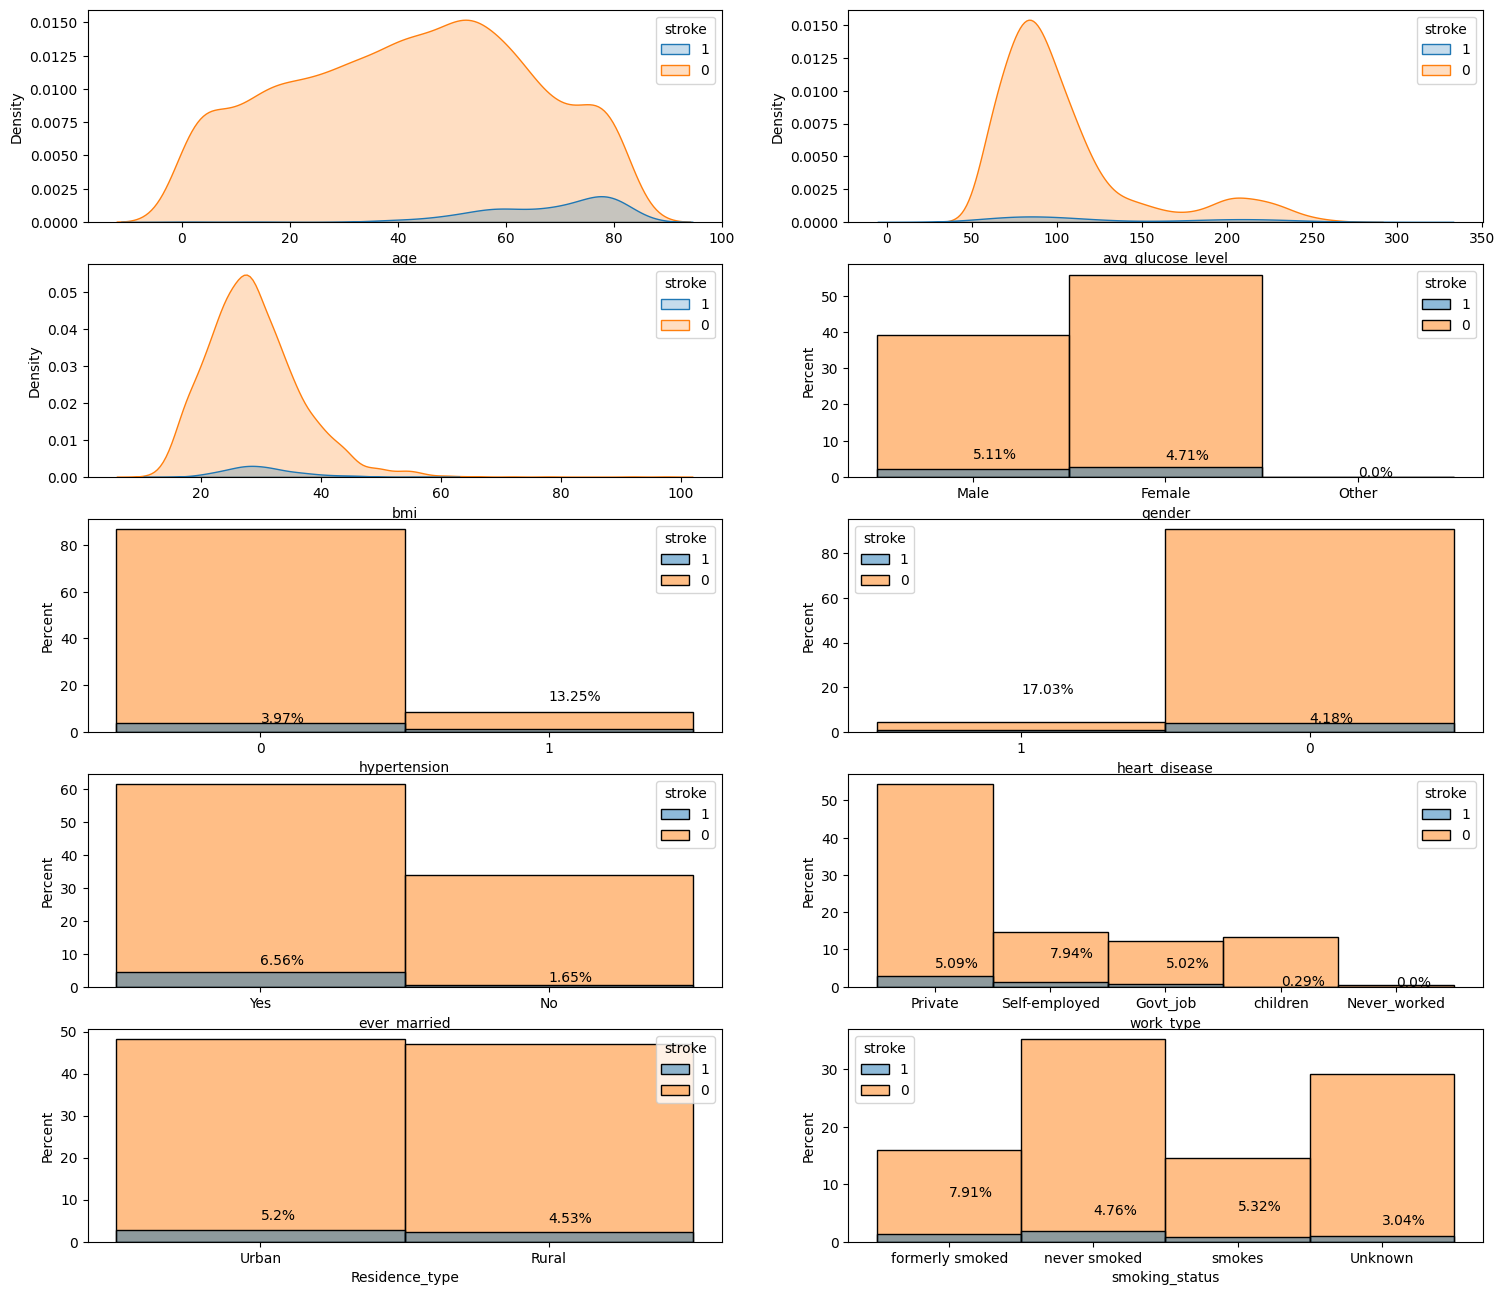

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(5, 2, figsize=(18, 16))
ax = ax.flatten()

numerical = ["age", "avg_glucose_level", "bmi"]
categorical = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]

# Numerical
for idx, attr in enumerate(numerical):
    sns.kdeplot(data=df, x=attr, hue="stroke", fill=True, ax=ax[idx])
# Categorical
for idx, attr in enumerate(categorical, start=3):
    sns.histplot(data=df, x=attr, hue="stroke", fill=True, ax=ax[idx], stat="percent")


    categories = [tick.get_text() for tick in ax[idx].get_xticklabels()]
    for category in categories:
        perc = df[(df[attr] == category) & (df['stroke'] == "1")].shape[0]/df[df[attr] == category].shape[0]
        x_pos = list(categories).index(category)
        ax[idx].text(
            x=x_pos,
            y=perc*100,
            s=f"{str(np.round(perc*100, decimals=2))}%"
        )



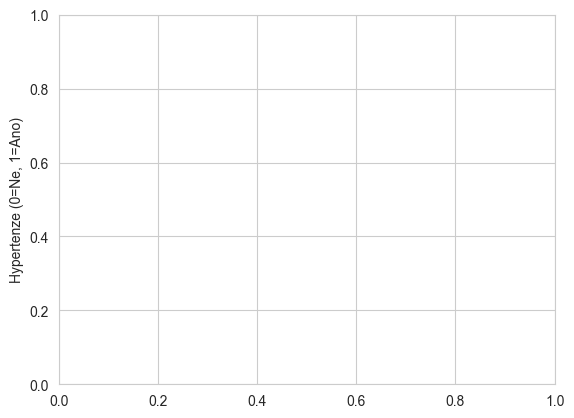

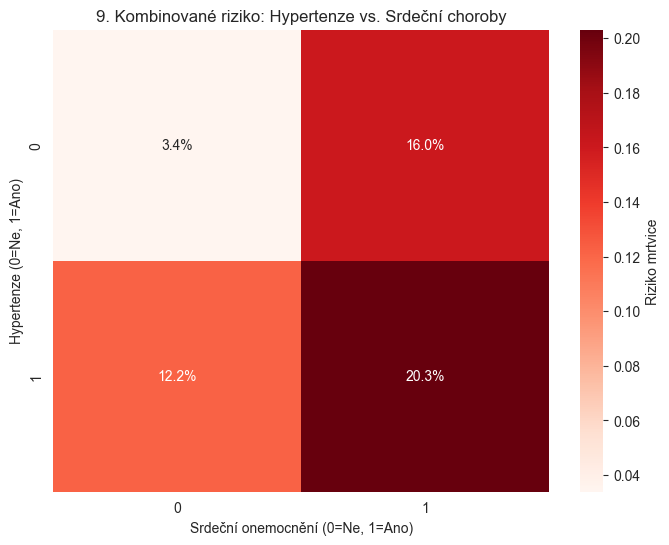

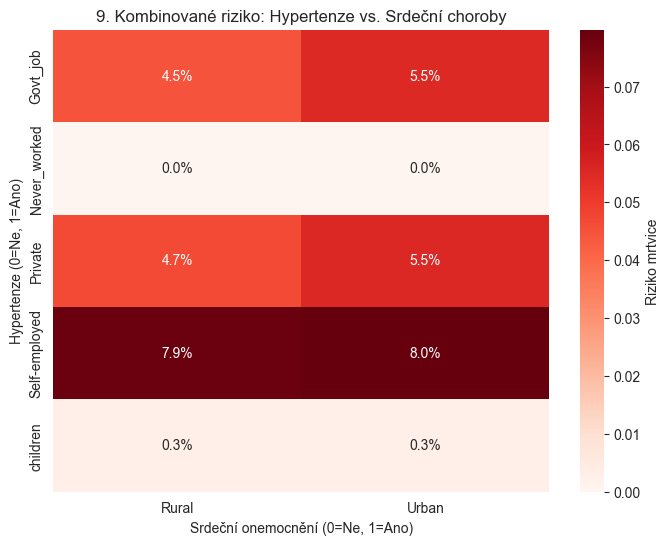

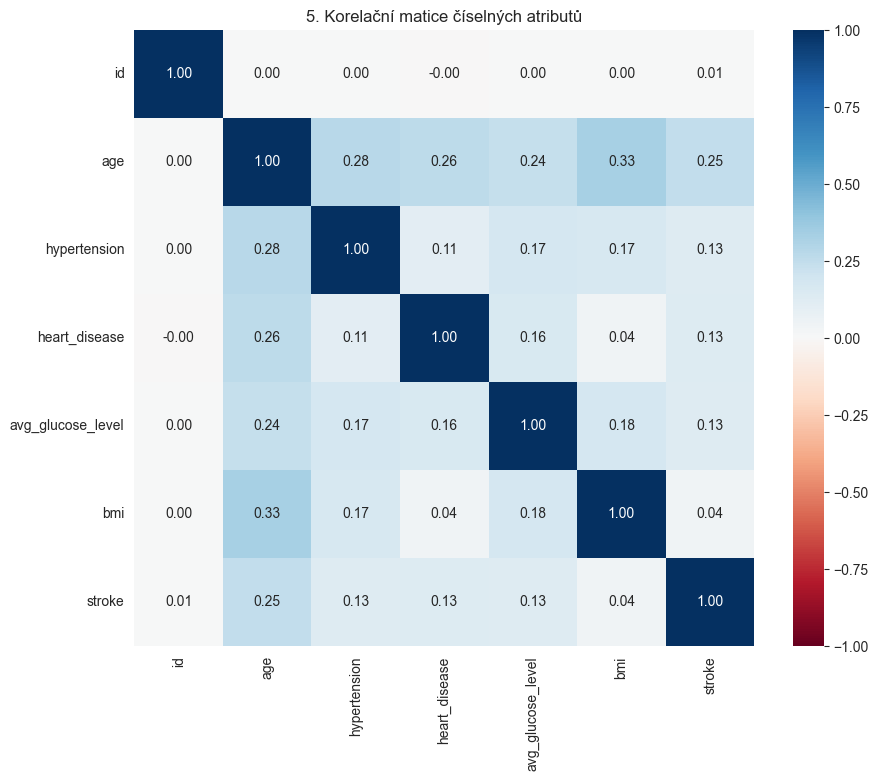

In [50]:
plt.ylabel('Hypertenze (0=Ne, 1=Ano)')

comorbidity_risk = pd.pivot_table(df, values='stroke', index='hypertension', 
                                  columns='heart_disease', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(comorbidity_risk, annot=True, fmt=".1%", cmap='Reds', cbar_kws={'label': 'Riziko mrtvice'})
plt.title('9. Kombinované riziko: Hypertenze vs. Srdeční choroby')
plt.xlabel('Srdeční onemocnění (0=Ne, 1=Ano)')
plt.ylabel('Hypertenze (0=Ne, 1=Ano)')
plt.show()

comorbidity_risk = pd.pivot_table(df, values='stroke', index='work_type', 
                                  columns='Residence_type', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(comorbidity_risk, annot=True, fmt=".1%", cmap='Reds', cbar_kws={'label': 'Riziko mrtvice'})
plt.title('9. Kombinované riziko: Hypertenze vs. Srdeční choroby')
plt.xlabel('Srdeční onemocnění (0=Ne, 1=Ano)')
plt.ylabel('Hypertenze (0=Ne, 1=Ano)')
plt.show()



# 5. Graf: Korelační matice (Heatmap)
# Pro korelaci vybereme pouze číselné sloupce
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('5. Korelační matice číselných atributů')
plt.show()

# Úprava datové sady